##### (a)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path

In [ ]:
MAX_POOL_SIZE = 5
CONVOLUTION_SIZE = 4
CONVOLUTION_FILTERS = 2

In [ ]:
def forward_softmax(x):
    """
    Compute softmax function for a single example.
    The shape of the input is of size # num classes.

    Important Note: You must be careful to avoid overflow for this function. Functions
    like softmax have a tendency to overflow when very large numbers like e^10000 are computed.
    You will know that your function is overflow resistent when it can handle input like:
    np.array([[10000, 10010, 10]]) without issues.

        x: A 1d numpy float array of shape number_of_classes

    Returns:
        A 1d numpy float array containing the softmax results of shape  number_of_classes
    """
    x = x - np.max(x,axis=0)
    exp = np.exp(x)
    s = exp / np.sum(exp,axis=0)
    return s

def backward_softmax(x, grad_outputs):
    """
    Compute the gradient of the loss with respect to x.

    grad_outputs is the gradient of the loss with respect to the outputs of the softmax.

    Args:
        x: A 1d numpy float array of shape number_of_classes
        grad_outputs: A 1d numpy float array of shape number_of_classes

    Returns:
        A 1d numpy float array of the same shape as x with the derivative of the loss with respect to x
    """
    
    # *** START CODE HERE ***
    return forward_softmax(x) - (grad_outputs!=0).astype(int)
    # *** END CODE HERE ***

def forward_relu(x):
    """
    Compute the relu function for the input x.

    Args:
        x: A numpy float array

    Returns:
        A numpy float array containing the relu results
    """
    x[x<=0] = 0

    return x

def backward_relu(x, grad_outputs):
    """
    Compute the gradient of the loss with respect to x

    Args:
        x: A numpy array of arbitrary shape containing the input.
        grad_outputs: A numpy array of the same shape of x containing the gradient of the loss with respect
            to the output of relu

    Returns:
        A numpy array of the same shape as x containing the gradients with respect to x.
    """

    # *** START CODE HERE ***
    grad_outputs[x<=0] = 0
    return grad_outputs
    # *** END CODE HERE ***

def get_initial_params():
    """
    Compute the initial parameters for the neural network.

    This function should return a dictionary mapping parameter names to numpy arrays containing
    the initial values for those parameters.

    There should be four parameters for this model:
    W1 is the weight matrix for the convolutional layer
    b1 is the bias vector for the convolutional layer
    W2 is the weight matrix for the output layers
    b2 is the bias vector for the output layer

    Weight matrices should be initialized with values drawn from a random normal distribution.
    The mean of that distribution should be 0.
    The variance of that distribution should be 1/sqrt(n) where n is the number of neurons that
    feed into an output for that layer.

    Bias vectors should be initialized with zero.
    
    
    Returns:
        A dict mapping parameter names to numpy arrays
    """

    size_after_convolution = 28 - CONVOLUTION_SIZE + 1
    size_after_max_pooling = size_after_convolution // MAX_POOL_SIZE

    num_hidden = size_after_max_pooling * size_after_max_pooling * CONVOLUTION_FILTERS

    return {
        'W1': np.random.normal(size = (CONVOLUTION_FILTERS, 1, CONVOLUTION_SIZE, CONVOLUTION_SIZE), scale=1/ math.sqrt(CONVOLUTION_SIZE * CONVOLUTION_SIZE)),
        'b1': np.zeros(CONVOLUTION_FILTERS),
        'W2': np.random.normal(size = (num_hidden, 10), scale = 1/ math.sqrt(num_hidden)),
        'b2': np.zeros(10)
    }

def forward_convolution(conv_W, conv_b, data):
    """
    Compute the output from a convolutional layer given the weights and data.

    conv_W is of the shape (# output channels, # input channels, convolution width, convolution height )
    conv_b is of the shape (# output channels)

    data is of the shape (# input channels, width, height)

    The output should be the result of a convolution and should be of the size:
        (# output channels, width - convolution width + 1, height -  convolution height + 1)

    Returns:
        The output of the convolution as a numpy array
    """

    conv_channels, _, conv_width, conv_height = conv_W.shape

    input_channels, input_width, input_height = data.shape

    output = np.zeros((conv_channels, input_width - conv_width + 1, input_height - conv_height + 1))

    for x in range(input_width - conv_width + 1):
        for y in range(input_height - conv_height + 1):
            for output_channel in range(conv_channels):
                output[output_channel, x, y] = np.sum(
                    np.multiply(data[:, x:(x + conv_width), y:(y + conv_height)], conv_W[output_channel, :, :, :])) + conv_b[output_channel]

    return output

def backward_convolution(conv_W, conv_b, data, output_grad):
    """
    Compute the gradient of the loss with respect to the parameters of the convolution.

    See forward_convolution for the sizes of the arguments.
    output_grad is the gradient of the loss with respect to the output of the convolution.

    Returns:
        A tuple containing 3 gradients.
        The first element is the gradient of the loss with respect to the convolution weights
        The second element is the gradient of the loss with respect to the convolution bias
        The third element is the gradient of the loss with respect to the input data
    """

    # *** START CODE HERE ***
    
    c_ch, _, c_w, c_h= conv_W.shape
    in_ch, in_w, in_h = data.shape
    
    grad_b = output_grad.sum(axis=(1,2))
    
    grad_W = np.zeros_like(conv_W) # (c_ch, in_ch, c_w, c_h)
    grad_data = np.zeros_like(data) # (in_ch, in_w, in_h)
    
    for x in range(in_w - c_w + 1):
        for y in range(in_h - c_h + 1):
            for c in range(c_ch):
                grad_W[c, :, :, :] += data[:, x:(x+c_w), y:(y+c_h)] * output_grad[c, x, y]
                grad_data[:, x:(x+c_w), y:(y+c_h)] += conv_W[c, :, :, :] * output_grad[c, x, y]
    
    return grad_W, grad_b, grad_data
    
    # *** END CODE HERE ***

def forward_max_pool(data, pool_width, pool_height):
    """
    Compute the output from a max pooling layer given the data and pool dimensions.

    The stride length should be equal to the pool size

    data is of the shape (# channels, width, height)

    The output should be the result of the max pooling layer and should be of size:
        (# channels, width // pool_width, height // pool_height)

    Returns:
        The result of the max pooling layer
    """
    input_channels, input_width, input_height = data.shape
    
    output = np.zeros((input_channels, input_width // pool_width, input_height // pool_height))

    for x in range(0, input_width, pool_width):
        for y in range(0, input_height, pool_height):

            output[:, x // pool_width, y // pool_height] = np.amax(data[:, x:(x + pool_width), y:(y + pool_height)], axis=(1, 2))

    return output

def backward_max_pool(data, p_w, p_h, output_grad):
    """
    Compute the gradient of the loss with respect to the data in the max pooling layer.

    data is of the shape (# channels, width, height)
    output_grad is of shape (# channels, width // pool_width, height // pool_height)

    output_grad is the gradient of the loss with respect to the output of the backward max
    pool layer.

    Returns:
        The gradient of the loss with respect to the data (of same shape as data)
    """
    
    # *** START CODE HERE ***
    c, w, h = data.shape
    
    grad_data = np.zeros((c, w, h))
    
    for x in range(0, w, p_w):
        for y in range(0, h, p_h):
                patch = data[:, x:(x+p_w), y:(y+p_h)].reshape(c, -1)
                l_x, l_y = np.unravel_index(np.argmax(patch, axis=-1), (p_w, p_h))
                grad_data[np.arange(c), x+l_x, y+l_y] += output_grad[:, x//p_w, y//p_h]
            
    return grad_data
    # *** END CODE HERE ***

def forward_cross_entropy_loss(probabilities, labels):
    """
    Compute the output from a cross entropy loss layer given the probabilities and labels.

    probabilities is of the shape (# classes)
    labels is of the shape (# classes)

    The output should be a scalar

    Returns:
        The result of the log loss layer
    """

    result = 0

    for i, label in enumerate(labels):
        if label == 1:
            result += -np.log(probabilities[i])

    return result

def backward_cross_entropy_loss(probabilities, labels):
    """
    Compute the gradient of the cross entropy loss with respect to the probabilities.

    probabilities is of the shape (# classes)
    labels is of the shape (# classes)

    The output should be the gradient with respect to the probabilities.

    Returns:
        The gradient of the loss with respect to the probabilities.
    """

    # *** START CODE HERE ***
    return -labels / probabilities
    # *** END CODE HERE ***

def forward_linear(weights, bias, data):
    """
    Compute the output from a linear layer with the given weights, bias and data.
    weights is of the shape (input # features, output # features)
    bias is of the shape (output # features)
    data is of the shape (input # features)

    The output should be of the shape (output # features)

    Returns:
        The result of the linear layer
    """
    return data.dot(weights) + bias

def backward_linear(weights, bias, data, output_grad):
    """
    Compute the gradients of the loss with respect to the parameters of a linear layer.

    See forward_linear for information about the shapes of the variables.

    output_grad is the gradient of the loss with respect to the output of this layer.

    This should return a tuple with three elements:
    - The gradient of the loss with respect to the weights
    - The gradient of the loss with respect to the bias
    - The gradient of the loss with respect to the data
    """

    # *** START CODE HERE ***
    grad_weights = np.outer(data, output_grad)
    grad_bias = output_grad
    grad_data = weights @ output_grad
    
    return grad_weights, grad_bias, grad_data
    # *** END CODE HERE ***

In [ ]:

def forward_prop(data, labels, params):
    """
    Implement the forward layer given the data, labels, and params.
    
    Args:
        data: A numpy array containing the input (shape is 1 by 28 by 28)
        labels: A 1d numpy array containing the labels (shape is 10)
        params: A dictionary mapping parameter names to numpy arrays with the parameters.
            This numpy array will contain W1, b1, W2 and b2
            W1 and b1 represent the weights and bias for the hidden layer of the network
            W2 and b2 represent the weights and bias for the output layer of the network

    Returns:
        A 2 element tuple containing:
            1. A numpy array The output (after the softmax) of the output layer
            2. The average loss for these data elements
    """

    W1 = params['W1']
    b1 = params['b1']
    W2 = params['W2']
    b2 = params['b2']

    first_convolution = forward_convolution(W1, b1, data)
    first_max_pool = forward_max_pool(first_convolution, MAX_POOL_SIZE, MAX_POOL_SIZE)
    first_after_relu = forward_relu(first_max_pool)

    flattened = np.reshape(first_after_relu, (-1))
    
    logits = forward_linear(W2, b2, flattened)

    y = forward_softmax(logits)
    cost = forward_cross_entropy_loss(y, labels)

    return y, cost

def backward_prop(data, labels, params):
    """
    Implement the backward propagation gradient computation step for a neural network
    
    Args:
        data: A numpy array containing the input for a single example
        labels: A 1d numpy array containing the labels for a single example
        params: A dictionary mapping parameter names to numpy arrays with the parameters.
            This numpy array will contain W1, b1, W2, and b2
            W1 and b1 represent the weights and bias for the convolutional layer
            W2 and b2 represent the weights and bias for the output layer of the network

    Returns:
        A dictionary of strings to numpy arrays where each key represents the name of a weight
        and the values represent the gradient of the loss with respect to that weight.
        
        In particular, it should have 4 elements:
            W1, W2, b1, and b2
    """

    # *** START CODE HERE ***
    W1 = params['W1']
    b1 = params['b1']
    W2 = params['W2']
    b2 = params['b2']

    first_convolution = forward_convolution(W1, b1, data)
    first_max_pool = forward_max_pool(first_convolution, MAX_POOL_SIZE, MAX_POOL_SIZE)
    
    first_after_relu = forward_relu(first_max_pool)
    flattened = np.reshape(first_after_relu, (-1))
    
    logits = forward_linear(W2, b2, flattened)
    y = forward_softmax(logits)
    
    cost = forward_cross_entropy_loss(y, labels)
    
    grad_CE = backward_cross_entropy_loss(y, labels)
    grad_softmax = backward_softmax(logits, grad_CE)
    grad_W2, grad_b2, grad_linear = backward_linear(W2, b2, flattened, grad_softmax)
    grad_linear = grad_linear.reshape(first_after_relu.shape)
    grad_relu = backward_relu(first_max_pool, grad_linear)
    grad_max_pool = backward_max_pool(first_convolution, MAX_POOL_SIZE, MAX_POOL_SIZE, grad_relu)
    grad_W1, grad_b1, grad_data = backward_convolution(W1, b1, data, grad_max_pool)
    
    return {
        "W1": grad_W1,
        "b1": grad_b1,
        "W2": grad_W2,
        "b2": grad_b2
    }, y, cost
    # *** END CODE HERE ***


In [ ]:

def forward_prop_batch(batch_data, batch_labels, params, forward_prop_func):
    """Apply the forward prop func to every image in a batch"""

    y_array = []
    cost_array = []

    for item, label in zip(batch_data, batch_labels):
        y, cost = forward_prop_func(item, label, params)
        y_array.append(y)
        cost_array.append(cost)

    return np.array(y_array), np.array(cost_array)

def gradient_descent_batch(batch_data, batch_labels, learning_rate, params, backward_prop_func):
    """
    Perform one batch of gradient descent on the given training data using the provided learning rate.

    This code should update the parameters stored in params.
    It should not return anything

    Args:
        batch_data: A numpy array containing the training data for the batch
        train_labels: A numpy array containing the training labels for the batch
        learning_rate: The learning rate
        params: A dict of parameter names to parameter values that should be updated.
        backward_prop_func: A function that follows the backwards_prop API

    Returns: This function returns nothing.
    """

    total_grad = {}
    
    total_loss = 0
    correct = 0

    for i in range(batch_data.shape[0]):
        grad, y, cost = backward_prop_func(
            batch_data[i, :, :],
            batch_labels[i, :],
            params)
        
        for key, value in grad.items():
            if key not in total_grad:
                total_grad[key] = np.zeros(value.shape)

            total_grad[key] += value
            
        total_loss += cost
        
        if np.argmax(y) == np.argmax(batch_labels[i]):
            correct += 1

    params['W1'] = params['W1'] - learning_rate * total_grad['W1']
    params['W2'] = params['W2'] - learning_rate * total_grad['W2']
    params['b1'] = params['b1'] - learning_rate * total_grad['b1']
    params['b2'] = params['b2'] - learning_rate * total_grad['b2']

    n = batch_data.shape[0]

    # This function does not return anything
    return total_loss / n, correct / n


In [ ]:
def one_hot_labels(labels):
    one_hot_labels = np.zeros((labels.size, 10))
    one_hot_labels[np.arange(labels.size),labels.astype(int)] = 1
    return one_hot_labels

def read_data(images_file, labels_file):
    x = np.loadtxt(images_file, delimiter=',')
    y = np.loadtxt(labels_file, delimiter=',')

    x = np.reshape(x, (x.shape[0], 1, 28, 28))

    return x, y

def load_training_checkpoint(weights_path):
    weights_path = Path(weights_path)

    if not weights_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {weights_path}")

    with np.load(weights_path) as saved:
        required = ("W1", "b1", "W2", "b2", "mean", "std")

        missing = [key for key in required if key not in saved.files]
        if missing:
            raise ValueError(f"Missing checkpoint entries: {missing}")

        params = {
            "W1": saved["W1"].copy(),
            "b1": saved["b1"].copy(),
            "W2": saved["W2"].copy(),
            "b2": saved["b2"].copy(),
        }

        mean = float(saved["mean"])
        std = float(saved["std"])

    # Check that checkpoint matches current architecture
    size_after_convolution = 28 - CONVOLUTION_SIZE + 1
    size_after_max_pooling = size_after_convolution // MAX_POOL_SIZE

    num_hidden = (
        size_after_max_pooling
        * size_after_max_pooling
        * CONVOLUTION_FILTERS
    )

    expected_shapes = {
        "W1": (
            CONVOLUTION_FILTERS,
            1,
            CONVOLUTION_SIZE,
            CONVOLUTION_SIZE,
        ),
        "b1": (CONVOLUTION_FILTERS,),
        "W2": (num_hidden, 10),
        "b2": (10,),
    }

    for key, expected_shape in expected_shapes.items():
        if params[key].shape != expected_shape:
            raise ValueError(
                f"{key} has shape {params[key].shape}, "
                f"expected {expected_shape}"
            )

    if std == 0:
        raise ValueError("Saved training std is 0.")

    return params, mean, std

In [ ]:
def nn_train(
    train_data,
    train_labels,
    dev_data,
    dev_labels,
    get_initial_params_func,
    forward_prop_func,
    backward_prop_func,
    learning_rate=1e-2,
    batch_size=16,
    num_epochs=1,
    initial_params=None,
    print_every=100
):

    if initial_params is None:
        params = get_initial_params_func()
    else:
        params = {
            key: value.copy()
            for key, value in initial_params.items()
        }

    m = train_data.shape[0]

    # Ceiling division -> use ALL samples
    num_batches = (m + batch_size - 1) // batch_size

    for epoch in range(num_epochs):

        for batch in range(num_batches):

            start = batch * batch_size
            end = min(start + batch_size, m)

            batch_data = train_data[start:end]
            batch_labels = train_labels[start:end]

            loss, accuracy = gradient_descent_batch(
                batch_data,
                batch_labels,
                learning_rate,
                params,
                backward_prop_func
            )

            # Printing is cheap; only do it occasionally
            if (
                batch == 0
                or (batch + 1) % print_every == 0
                or batch == num_batches - 1
            ):
                print(
                    f"Epoch {epoch + 1}/{num_epochs} | "
                    f"batch {batch + 1}/{num_batches} | "
                    f"loss={loss:.4f} | "
                    f"accuracy={accuracy:.3f}"
                )

    return params

def nn_test(data, labels, params):
    output, cost = forward_prop(data, labels, params)
    accuracy = compute_accuracy(output, labels)
    return accuracy

def compute_accuracy(output, labels):
    correct_output = np.argmax(output,axis=1)
    correct_labels = np.argmax(labels,axis=1)

    is_correct = [a == b for a,b in zip(correct_output, correct_labels)]

    accuracy = sum(is_correct) * 1. / labels.shape[0]
    return accuracy

In [ ]:
def run_train(
    all_data,
    all_labels,
    backward_prop_func,
    initial_params=None,
    mean=None,
    std=None
):

    params = nn_train(
        all_data["train"],
        all_labels["train"],
        all_data["dev"],
        all_labels["dev"],
        get_initial_params,
        forward_prop,
        backward_prop_func,

        learning_rate=1e-2,
        batch_size=16,
        num_epochs=1,

        initial_params=initial_params,

        print_every=100
    )

    Path("output").mkdir(exist_ok=True)

    np.savez(
        "output/model_weights.npz",
        W1=params["W1"],
        b1=params["b1"],
        W2=params["W2"],
        b2=params["b2"],
        mean=mean,
        std=std,
    )

    print("Saved model to output/model_weights.npz")

    return params

In [ ]:
LOAD_WEIGHTS = True
WEIGHTS_PATH = "output/model_weights.npz"


np.random.seed(100)

train_data, train_labels = read_data(
    'data/images_train.csv',
    'data/labels_train.csv'
)

train_labels = one_hot_labels(train_labels)

p = np.random.permutation(60000)
train_data = train_data[p, :]
train_labels = train_labels[p, :]

dev_data = train_data[0:400, :]
dev_labels = train_labels[0:400, :]

train_data = train_data[400:, :]
train_labels = train_labels[400:, :]


if LOAD_WEIGHTS:
    initial_params, mean, std = load_training_checkpoint(
        WEIGHTS_PATH
    )

    print(f"Loaded weights from {WEIGHTS_PATH}")

else:
    initial_params = None

    mean = np.mean(train_data)
    std = np.std(train_data)

    print("Starting with new weights")


# Use either the saved normalization or newly calculated one
train_data = (train_data - mean) / std
dev_data = (dev_data - mean) / std


all_data = {
    'train': train_data,
    'dev': dev_data,
}

all_labels = {
    'train': train_labels,
    'dev': dev_labels,
}


# run_train(
#     all_data,
#     all_labels,
#     backward_prop,
#     initial_params=initial_params,
#     mean=mean,
#     std=std
# )

Loaded weights from output/model_weights.npz


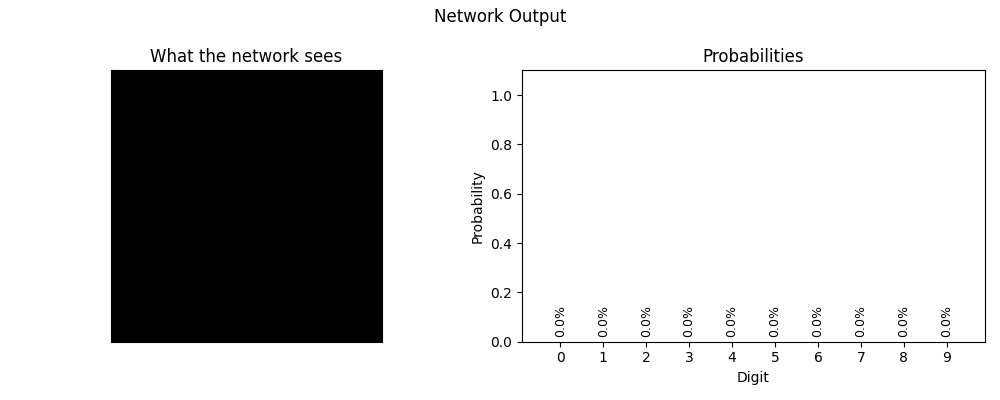

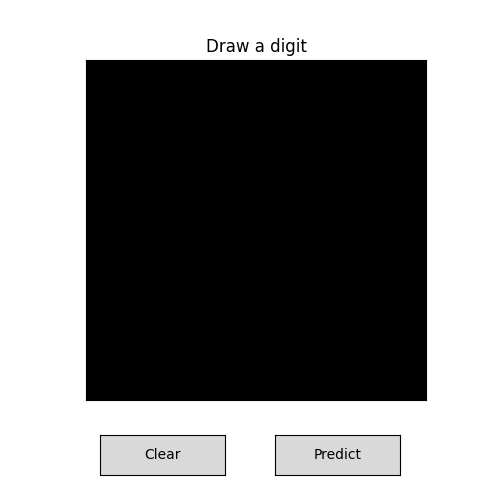

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button


# ============================================================
# Load trained model
# ============================================================

saved = np.load("output/model_weights.npz")

params = {
    "W1": saved["W1"],
    "b1": saved["b1"],
    "W2": saved["W2"],
    "b2": saved["b2"],
}


# Get training mean/std
if "mean" in saved.files and "std" in saved.files:
    TRAIN_MEAN = float(saved["mean"])
    TRAIN_STD = float(saved["std"])

elif "mean" in globals() and "std" in globals():
    TRAIN_MEAN = float(mean)
    TRAIN_STD = float(std)

else:
    raise RuntimeError(
        "Need the mean/std used during training. "
        "Save them with the model or define `mean` and `std` first."
    )


# ============================================================
# Model prediction
# ============================================================

def predict(img_28):
    """
    img_28:
        shape (28, 28)
        pixel values 0..255
    """

    # Normalize exactly like training
    x = (img_28 - TRAIN_MEAN) / TRAIN_STD

    # Add channel dimension
    x = x.reshape(1, 28, 28)

    # Convolution
    conv = forward_convolution(
        params["W1"],
        params["b1"],
        x
    )

    # Max pooling
    pool = forward_max_pool(
        conv,
        MAX_POOL_SIZE,
        MAX_POOL_SIZE
    )

    # ReLU
    relu = forward_relu(pool)

    # Flatten
    flattened = relu.reshape(-1)

    # Final linear layer
    logits = forward_linear(
        params["W2"],
        params["b2"],
        flattened
    )

    # Convert logits to probabilities
    probs = forward_softmax(logits)

    return probs


# ============================================================
# Drawing canvas settings
# ============================================================

CANVAS_SIZE = 280
BRUSH_RADIUS = 12

canvas = np.zeros(
    (CANVAS_SIZE, CANVAS_SIZE),
    dtype=np.float32
)

drawing = False
last_point = None


# ============================================================
# Main drawing figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(5, 5)
)

# Leave room at bottom for buttons
fig.subplots_adjust(bottom=0.20)

image_display = ax.imshow(
    canvas,
    cmap="gray",
    vmin=0,
    vmax=255,
    origin="upper"
)

ax.set_title("Draw a digit")
ax.set_xticks([])
ax.set_yticks([])


# ============================================================
# Drawing functions
# ============================================================

def stamp(x, y):
    """
    Draw a circular brush stamp at x, y.
    """

    x = int(x)
    y = int(y)

    x0 = max(
        0,
        x - BRUSH_RADIUS
    )

    x1 = min(
        CANVAS_SIZE,
        x + BRUSH_RADIUS + 1
    )

    y0 = max(
        0,
        y - BRUSH_RADIUS
    )

    y1 = min(
        CANVAS_SIZE,
        y + BRUSH_RADIUS + 1
    )

    yy, xx = np.ogrid[
        y0:y1,
        x0:x1
    ]

    mask = (
        (xx - x) ** 2 +
        (yy - y) ** 2
        <= BRUSH_RADIUS ** 2
    )

    patch = canvas[
        y0:y1,
        x0:x1
    ]

    patch[mask] = 255


def draw_line(x0, y0, x1, y1):
    """
    Draw stamps between two mouse positions so
    fast mouse movement doesn't leave gaps.
    """

    distance = np.hypot(
        x1 - x0,
        y1 - y0
    )

    steps = max(
        1,
        int(
            distance /
            (BRUSH_RADIUS / 2)
        )
    )

    for t in np.linspace(
        0,
        1,
        steps + 1
    ):

        x = x0 + t * (x1 - x0)
        y = y0 + t * (y1 - y0)

        stamp(x, y)


# ============================================================
# Mouse events
# ============================================================

def on_press(event):
    global drawing
    global last_point

    # Only draw inside drawing axes
    if event.inaxes != ax:
        return

    if (
        event.xdata is None
        or event.ydata is None
    ):
        return

    drawing = True

    last_point = (
        event.xdata,
        event.ydata
    )

    stamp(
        event.xdata,
        event.ydata
    )

    image_display.set_data(canvas)

    fig.canvas.draw_idle()


def on_motion(event):
    global last_point

    if not drawing:
        return

    if event.inaxes != ax:
        return

    if (
        event.xdata is None
        or event.ydata is None
    ):
        return

    x = event.xdata
    y = event.ydata

    if last_point is not None:

        draw_line(
            last_point[0],
            last_point[1],
            x,
            y
        )

    last_point = (
        x,
        y
    )

    image_display.set_data(canvas)

    fig.canvas.draw_idle()


def on_release(event):
    global drawing
    global last_point

    drawing = False
    last_point = None


# ============================================================
# Results figure
#
# Created ONCE.
# Predict will update this figure instead of creating new ones.
# ============================================================

results_fig, (
    network_ax,
    prob_ax
) = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)

results_fig.suptitle(
    "Network Output"
)


# ------------------------------------------------------------
# Left side:
# What the network actually sees
# ------------------------------------------------------------

network_img = network_ax.imshow(
    np.zeros((28, 28)),
    cmap="gray",
    vmin=0,
    vmax=255,
    origin="upper"
)

network_ax.set_title(
    "What the network sees"
)

network_ax.set_xticks([])
network_ax.set_yticks([])


# ------------------------------------------------------------
# Right side:
# Prediction probabilities
# ------------------------------------------------------------

digits = np.arange(10)

prob_bars = prob_ax.bar(
    digits,
    np.zeros(10)
)

prob_ax.set_title(
    "Probabilities"
)

prob_ax.set_xlabel(
    "Digit"
)

prob_ax.set_ylabel(
    "Probability"
)

prob_ax.set_xticks(
    digits
)

prob_ax.set_ylim(
    0,
    1.10
)


# ------------------------------------------------------------
# Probability percentage labels
# ------------------------------------------------------------

prob_texts = []

for digit in digits:

    text = prob_ax.text(
        digit,
        0.02,
        "0.0%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

    prob_texts.append(text)


results_fig.tight_layout()


# ============================================================
# Buttons
# ============================================================

# IMPORTANT:
# Use fig.add_axes() so the buttons belong specifically
# to the drawing figure, not whichever figure is currently active.

clear_ax = fig.add_axes(
    [
        0.20,
        0.05,
        0.25,
        0.08
    ]
)

predict_ax = fig.add_axes(
    [
        0.55,
        0.05,
        0.25,
        0.08
    ]
)

clear_button = Button(
    clear_ax,
    "Clear"
)

predict_button = Button(
    predict_ax,
    "Predict"
)


# ============================================================
# Clear button
# ============================================================

def clear(event):

    # Clear drawing canvas
    canvas[:] = 0

    image_display.set_data(
        canvas
    )

    ax.set_title(
        "Draw a digit"
    )


    # Reset network input image
    network_img.set_data(
        np.zeros((28, 28))
    )

    network_ax.set_title(
        "What the network sees"
    )


    # Reset probability bars
    for bar, text in zip(
        prob_bars,
        prob_texts
    ):

        bar.set_height(0)

        text.set_y(
            0.02
        )

        text.set_text(
            "0.0%"
        )


    prob_ax.set_title(
        "Probabilities"
    )


    # Refresh both figures
    fig.canvas.draw_idle()
    results_fig.canvas.draw_idle()


# ============================================================
# Predict button
# ============================================================

def run_prediction(event):

    # --------------------------------------------------------
    # Downsample 280x280 -> 28x28
    #
    # Every 10x10 region of the drawing canvas becomes
    # one pixel in the network input.
    # --------------------------------------------------------

    img_28 = canvas.reshape(
        28,
        10,
        28,
        10
    ).mean(
        axis=(1, 3)
    ).T


    # --------------------------------------------------------
    # Run CNN
    # --------------------------------------------------------

    probs = np.asarray(
        predict(img_28)
    ).ravel()


    predicted = int(
        np.argmax(probs)
    )


    confidence = (
        probs[predicted] * 100
    )


    # --------------------------------------------------------
    # Update drawing window title
    # --------------------------------------------------------

    ax.set_title(
        f"Prediction: {predicted} "
        f"({confidence:.1f}%)"
    )


    # --------------------------------------------------------
    # Update network input image
    #
    # This OVERWRITES the previous 28x28 image.
    # No new figure is created.
    # --------------------------------------------------------

    network_img.set_data(
        img_28.T
    )

    network_ax.set_title(
        "What the network sees\n"
        f"Prediction: {predicted}"
    )


    # --------------------------------------------------------
    # Update probability bars
    #
    # This OVERWRITES the previous probabilities.
    # --------------------------------------------------------

    for digit, (
        bar,
        probability,
        text
    ) in enumerate(
        zip(
            prob_bars,
            probs,
            prob_texts
        )
    ):

        bar.set_height(
            probability
        )

        text.set_y(
            probability + 0.015
        )

        text.set_text(
            f"{probability * 100:.1f}%"
        )


    prob_ax.set_title(
        f"Prediction: {predicted} "
        f"({confidence:.1f}%)"
    )


    # --------------------------------------------------------
    # Refresh both existing figures
    # --------------------------------------------------------

    fig.canvas.draw_idle()

    results_fig.canvas.draw_idle()


# ============================================================
# Connect buttons
#
# ONLY CONNECT THESE ONCE
# ============================================================

clear_button.on_clicked(
    clear
)

predict_button.on_clicked(
    run_prediction
)


# ============================================================
# Connect drawing mouse events
#
# ONLY CONNECT THESE ONCE
# ============================================================

fig.canvas.mpl_connect(
    "button_press_event",
    on_press
)

fig.canvas.mpl_connect(
    "motion_notify_event",
    on_motion
)

fig.canvas.mpl_connect(
    "button_release_event",
    on_release
)


# ============================================================
# Show figures
# ============================================================

plt.show()

In [1]:
test_data, test_labels = read_data(
    'data/images_test.csv',
    'data/labels_test.csv'
)

img = test_data[1].squeeze(0).T
label = test_labels[1]
probs = predict(img)

plt.figure()
plt.imshow(img, cmap="gray")
plt.title(
    f"Prediction: {np.argmax(probs)} Actual: {label}"
    f"({np.max(probs)*100:.1f}%)"
)
plt.show()

NameError: name 'read_data' is not defined